# 1. Given a small dataset of 2D points representing food delivery locations (e.g., [2,3], [5,8], [1,2], [6,9], [7,7]), plot the points on graph paper or using matplotlib, randomly pick two initial centroids, and manually assign each point to the nearest centroid using Euclidean distance.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
points = np.array([[2, 3], [5, 8], [1, 2], [6, 9], [7, 7]])
centroids = np.array([[2, 3], [7, 7]])

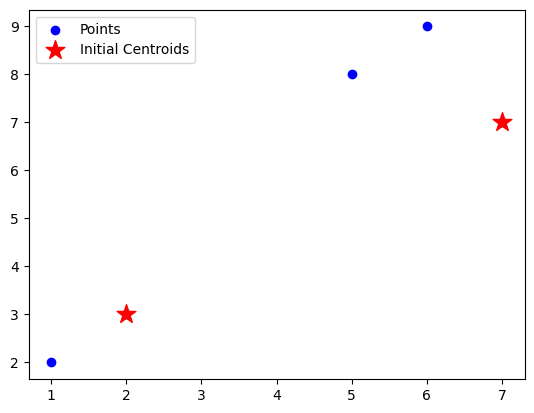

In [5]:
plt.scatter(points[:, 0], points[:, 1], color="blue", label="Points")
plt.scatter(centroids[:, 0], centroids[:, 1], color="red", marker="*", s=200, label="Initial Centroids")
plt.legend()
plt.show()

In [6]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

In [7]:
assignments = [0 if euclidean_distance(p, centroids[0]) < euclidean_distance(p, centroids[1]) else 1 for p in points]
print("Manual Assignments:", assignments)

Manual Assignments: [0, 1, 0, 1, 1]


# 2. Write a Python function assign_clusters(points, centroids) that takes a list of points and a list of centroids, and returns a list showing which cluster each point belongs to using Euclidean distance.

In [8]:
def assign_clusters(points, centroids):
    
    assignments = []
    
    for p in points:
        distances = [np.sqrt(np.sum((p - c)**2)) for c in centroids]
        
        assignments.append(np.argmin(distances))
        print(distances)
        
    return assignments

In [9]:
clusters = assign_clusters(points, centroids)
print("Assignments:", clusters)

[np.float64(0.0), np.float64(6.4031242374328485)]
[np.float64(5.830951894845301), np.float64(2.23606797749979)]
[np.float64(1.4142135623730951), np.float64(7.810249675906654)]
[np.float64(7.211102550927978), np.float64(2.23606797749979)]
[np.float64(6.4031242374328485), np.float64(0.0)]
Assignments: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


# 3 Update your assign_clusters code to work with Manhattan distance as well. Allow the user to choose between 'euclidean' and 'manhattan' as a parameter.


In [10]:
def assign_clusters_updated(points, centroids, metric):
    if metric == "euclidean":
        return [np.argmin([np.sqrt(np.sum((p - c)**2)) for c in centroids]) for p in points]
    elif metric == "manhattan":
        return [np.argmin([np.sum(np.abs(p - c)) for c in centroids]) for p in points]

print("Euclidean:", assign_clusters_updated(points, centroids, metric="euclidean"))
print("Manhattan:", assign_clusters_updated(points, centroids, metric="manhattan"))

Euclidean: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]
Manhattan: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


# 4 Implement a function update_centroids(points, assignments, k) that calculates the new centroid for each cluster as the mean of the assigned points. Test it with a sample dataset of your choice.

In [11]:
def update_centroids(points, assignments, k):
    new_centroids = []
    for i in range(k):

        cluster_points = [points[j] for j in range(len(points)) if assignments[j] == i]
        if len(cluster_points) > 0:
            new_centroids.append(np.mean(cluster_points, axis=0))
        else:
            new_centroids.append(points[np.random.choice(len(points))])
                    
    return np.array(new_centroids)

In [12]:
new_cents = update_centroids(points, clusters, 2)
print("Updated Centroids:\n", new_cents)

Updated Centroids:
 [[1.5 2.5]
 [6.  8. ]]


# 5 Use the Elbow Method to determine the optimal number of clusters (k) for a dataset of your choice (e.g., favorite songs by tempo and danceability, or Zomato restaurant ratings and price). Plot the within-cluster sum of squares for k=1 to k=6 and identify the 'elbow' point.<br><br><em><strong>Hint:</strong> Use sklearn's KMeans and matplotlib for plotting.</em>

In [13]:
import pandas as pd
from sklearn.cluster import KMeans

In [14]:
data = {
    "Ratings": [4.2, 4.5, 3.8, 4.0, 4.8, 3.5, 4.1, 4.7, 3.9, 4.6, 4.3, 3.7, 4.9, 4.4, 3.6],
    "Price": [500, 1200, 300, 600, 1500, 200, 550, 1400, 400, 1300, 700, 250, 1600, 900, 350]
}

In [15]:
df = pd.DataFrame(data)
df

,Ratings,Price
0,4.2,500
1,4.5,1200
2,3.8,300
3,4.0,600
4,4.8,1500
5,3.5,200
6,4.1,550
7,4.7,1400
8,3.9,400
9,4.6,1300


In [18]:
wcss = []

for i in range(1, 7):
    
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

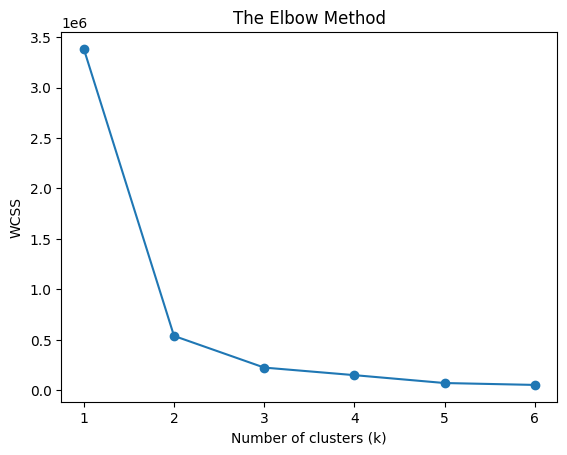

In [19]:
plt.plot(range(1, 7), wcss, marker="o")
plt.title("The Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()